## Import Required Libraries

Import necessary libraries for data analysis, exploration, and recommendations.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import os
import ast
import plotly.graph_objects as go
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

## Load Dataset Using Pandas

Load the CSV datasets from the archive folder.

In [2]:
# Define archive folder path
archive_path = Path('../data/raw')

# Load tracks dataset
tracks_df = pd.read_csv(archive_path / 'tracks.csv')
print("Tracks dataset loaded successfully!")
print(f"Shape: {tracks_df.shape}\n")
print("First few rows of tracks dataset:")
tracks_df.head()

Tracks dataset loaded successfully!
Shape: (586672, 20)

First few rows of tracks dataset:


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.4450,0,-13.338,1,0.4510,0.674,0.7440,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.2630,0,-22.136,1,0.9570,0.797,0.0000,0.148,0.655,102.009,1
2,07A5yehtSnoedViJAZkNnc,Vivo para Quererte - Remasterizado,0,181640,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.434,0.1770,1,-21.180,1,0.0512,0.994,0.0218,0.212,0.457,130.418,5
3,08FmqUhxtyLTn6pAh6bk45,El Prisionero - Remasterizado,0,176907,0,['Ignacio Corsini'],['5LiOoJbxVSAMkBS2fUm3X2'],1922-03-21,0.321,0.0946,7,-27.961,1,0.0504,0.995,0.9180,0.104,0.397,169.980,3
4,08y9GfoqCWfOGsKdwojr5e,Lady of the Evening,0,163080,0,['Dick Haymes'],['3BiJGZsyX9sJchTqcSA7Su'],1922,0.402,0.1580,3,-16.900,0,0.0390,0.989,0.1300,0.311,0.196,103.220,4


## Inspect Columns and Data Types

Examine the structure of the datasets, including column names and their data types.

In [3]:
print("=" * 80)
print("TRACKS DATASET STRUCTURE")
print("=" * 80)
print("\nData Types:")
print(tracks_df.dtypes)
print("\nDataset Info:")
tracks_df.info()
print("\nColumn Summary:")
print(f"Total Columns: {len(tracks_df.columns)}")
print(f"\nColumns: {list(tracks_df.columns)}")

TRACKS DATASET STRUCTURE

Data Types:
id                   object
name                 object
popularity            int64
duration_ms           int64
explicit              int64
artists              object
id_artists           object
release_date         object
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 586672 entries, 0 to 586671
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                586672 non-null  object 
 1   name              586601 non-null  object 
 2   popularity        586672 non-null  int64  
 3   duration_ms      

## Check Dataset Size

Display the shape and dimensions of both datasets.

In [4]:
print("=" * 80)
print("DATASET DIMENSIONS")
print("=" * 80)
print(f"\nTracks Dataset:")
print(f"  - Rows: {tracks_df.shape[0]:,}")
print(f"  - Columns: {tracks_df.shape[1]}")
print(f"  - Total cells: {tracks_df.shape[0] * tracks_df.shape[1]:,}")


DATASET DIMENSIONS

Tracks Dataset:
  - Rows: 586,672
  - Columns: 20
  - Total cells: 11,733,440


## Identify Missing Values

Check for and visualize missing values in both datasets.

MISSING VALUES - TRACKS DATASET

Missing Values Summary:
Column  Missing Count  Percentage
  name             71    0.012102


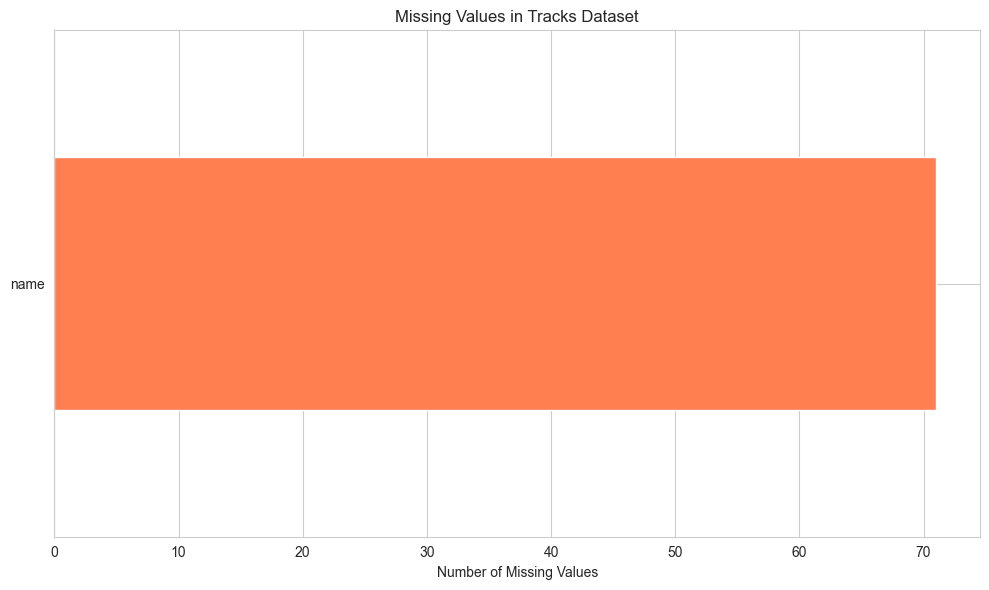

In [5]:
print("=" * 80)
print("MISSING VALUES - TRACKS DATASET")
print("=" * 80)

missing_tracks = tracks_df.isnull().sum()
missing_tracks_pct = (missing_tracks / len(tracks_df)) * 100

missing_tracks_df = pd.DataFrame({
    'Column': missing_tracks.index,
    'Missing Count': missing_tracks.values,
    'Percentage': missing_tracks_pct.values
})
missing_tracks_df = missing_tracks_df[missing_tracks_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_tracks_df) == 0:
    print("\nNo missing values found in tracks dataset!")
else:
    print("\nMissing Values Summary:")
    print(missing_tracks_df.to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_counts = tracks_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
if len(missing_counts) > 0:
    missing_counts.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('Number of Missing Values')
    ax.set_title('Missing Values in Tracks Dataset')
    plt.tight_layout()
    plt.show()
else:
    print("\nNo missing values to visualize.")

## Identify Duplicate Rows

Check for duplicate rows in both datasets.

In [6]:
print("=" * 80)
print("DUPLICATE ROWS - TRACKS DATASET")
print("=" * 80)

# Check for complete duplicate rows
duplicate_rows_tracks = tracks_df.duplicated().sum()
print(f"\nTotal completely duplicate rows: {duplicate_rows_tracks}")

# Check for duplicates based on first column (usually ID)
if len(tracks_df.columns) > 0:
    first_col = tracks_df.columns[0]
    duplicate_ids = tracks_df[first_col].duplicated().sum()
    print(f"Duplicate values in '{first_col}': {duplicate_ids}")

if duplicate_rows_tracks > 0:
    print("\nSample of duplicate rows:")
    duplicate_mask = tracks_df.duplicated(keep=False)
    print(tracks_df[duplicate_mask].sort_values(by=list(tracks_df.columns[:2])).head(10))
else:
    print("\nNo complete duplicate rows found.")

DUPLICATE ROWS - TRACKS DATASET

Total completely duplicate rows: 0
Duplicate values in 'id': 0

No complete duplicate rows found.


## Remove Duplicates

In [7]:
print("=" * 80)
print("REMOVE DUPLICATES")
print("=" * 80)

before = len(tracks_df)
tracks_cleaned = tracks_df.drop_duplicates().copy()
after = len(tracks_cleaned)

print(f"Rows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Removed:     {before - after:,} duplicate rows")

REMOVE DUPLICATES
Rows before: 586,672
Rows after:  586,672
Removed:     0 duplicate rows


## Handle Missing Values

In [8]:
print("=" * 80)
print("HANDLE MISSING VALUES")
print("=" * 80)

before_missing = tracks_cleaned['name'].isnull().sum()
before_rows = len(tracks_cleaned)

# Drop rows where 'name' is missing
tracks_cleaned = tracks_cleaned.dropna(subset=['name'])

after_missing = tracks_cleaned['name'].isnull().sum()
after_rows = len(tracks_cleaned)

print(f"'name' missing before: {before_missing}")
print(f"'name' missing after:  {after_missing}")
print(f"\nRows before: {before_rows:,}")
print(f"Rows after:  {after_rows:,}")
print(f"Rows removed: {before_rows - after_rows:,}")

# Confirm no missing values remain
total_missing = tracks_cleaned.isnull().sum().sum()
print(f"\nTotal missing values remaining: {total_missing}")

HANDLE MISSING VALUES
'name' missing before: 71
'name' missing after:  0

Rows before: 586,672
Rows after:  586,601
Rows removed: 71

Total missing values remaining: 0


## Fix Incorrect Data Types

In [11]:
print("=" * 80)
print("FIX DATA TYPES")
print("=" * 80)

# Convert artists from string to list
def to_list(value, placeholder):
    if isinstance(value, str):
        value = value.strip()
        if value == "":
            return [placeholder]
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list) and len(parsed) > 0:
                return parsed
            return [placeholder]
        except (ValueError, SyntaxError):
            return [placeholder]
    return [placeholder]

tracks_cleaned["artists"] = tracks_cleaned["artists"].apply(
    lambda x: to_list(x, "Unknown Artist")
)
tracks_cleaned["id_artists"] = tracks_cleaned["id_artists"].apply(
    lambda x: to_list(x, "unknown_artist_id")
)

# Convert 'explicit' and 'mode' from int to bool
tracks_cleaned['explicit'] = tracks_cleaned['explicit'].astype(bool)
tracks_cleaned['mode'] = tracks_cleaned['mode'].astype(bool)

# Extract only the year from 'release_date' into a new column 'release_year'
tracks_cleaned['release_year'] = pd.to_numeric(
    tracks_cleaned['release_date'].str[:4], errors='coerce'
)

# Drop rows where year could not be parsed
before_rows = len(tracks_cleaned)
tracks_cleaned = tracks_cleaned.dropna(subset=['release_year'])
tracks_cleaned['release_year'] = tracks_cleaned['release_year'].astype(int)
after_rows = len(tracks_cleaned)

tracks_cleaned = tracks_cleaned.drop(columns=['release_date'])

# Verify changes
print("\nartists sample:", tracks_cleaned.loc[0, "artists"], type(tracks_cleaned.loc[0, "artists"]))
print("id_artists sample:", tracks_cleaned.loc[0, "id_artists"], type(tracks_cleaned.loc[0, "id_artists"]))

print("\nUpdated Data Types:")
print(tracks_cleaned[['artists', 'id_artists', 'explicit', 'mode', 'release_year']].dtypes)

print("\nSample of fixed columns:")
print(tracks_cleaned[['name', 'explicit', 'mode', 'release_year']].head())

FIX DATA TYPES

artists sample: ['Uli'] <class 'list'>
id_artists sample: ['45tIt06XoI0Iio4LBEVpls'] <class 'list'>

Updated Data Types:
artists         object
id_artists      object
explicit          bool
mode              bool
release_year     int64
dtype: object

Sample of fixed columns:
                                  name  explicit   mode  release_year
0                                Carve     False   True          1922
1  Capítulo 2.16 - Banquero Anarquista     False   True          1922
2   Vivo para Quererte - Remasterizado     False   True          1922
3        El Prisionero - Remasterizado     False   True          1922
4                  Lady of the Evening     False  False          1922


## Preprocessing for the models 

In [13]:
# Select audio features
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
                      'instrumentalness', 'liveness', 'valence', 'tempo']
df_features = tracks_df[audio_features]

# --- Preprocessing: Scale the features ---
scaler = StandardScaler()
df_features_scaled = scaler.fit_transform(df_features)
df_features_scaled = pd.DataFrame(df_features_scaled, columns=audio_features)

print("\n--- Scaled Features Sample ---")
print(df_features_scaled.head())




--- Scaled Features Sample ---
   danceability    energy       key  loudness      mode  speechiness  \
0      0.490096 -0.385182 -1.483654 -0.615393  0.719665     1.924128   
1      0.791115 -1.107625 -1.483654 -2.344110  0.719665     4.736917   
2     -0.780204 -1.449000 -1.199517 -2.156266  0.719665    -0.298309   
3     -1.460507 -1.776084  0.505310 -3.488663  0.719665    -0.302756   
4     -0.972856 -1.524420 -0.631241 -1.315289 -1.389536    -0.366127   

   acousticness  instrumentalness  liveness   valence     tempo  
0      0.642528          2.362779 -0.341434 -1.650527 -0.457392  
1      0.995129         -0.425120 -0.357710  0.398600 -0.552876  
2      1.559864         -0.343432 -0.010498 -0.369823  0.401596  
3      1.562730          3.014787 -0.596418 -0.602678  1.730782  
4      1.545530          0.062013  0.526596 -1.382743 -0.512190  


## Recommender System Implementations

In [46]:
# Utility function to get track details from the dataframe
def get_track_details(track_name, df=tracks_df):
    """Fetches the first matching track's details from the dataframe."""
    track_query = df.loc[df['name'].str.lower() == track_name.lower()]
    if not track_query.empty:
        return track_query.iloc[0]
    return None # Return None if not found

# Utility function to display recommendations
def display_recommendations(recommendations_df):
    """Prints recommendations in a readable format."""
    print("\n--- Top Recommendations ---")
    for idx, row in recommendations_df.iterrows():
        # Using .get() for safer access to artist list
        artists = row.get('artists', 'Unknown Artist')
        print(f"  - {row['name']} by {artists}")

# --- Content-Based Recommender Using Cosine Similarity---
def content_based_recommender(track_name, n_recommendations=10, display=True):
    """Recommends songs based on cosine similarity of audio features."""
    if tracks_df.empty:
        print("Data not loaded. Cannot provide recommendations.")
        return pd.DataFrame()

    # Find the track
    track_details = get_track_details(track_name)
    if track_details is None:
        print(f"Track '{track_name}' not found in the dataset.")
        return pd.DataFrame()

    track_index = track_details.name # Get the index of the track
    track_features = df_features_scaled.loc[track_index].values.reshape(1, -1)

    # Calculate cosine similarity between the input track and all other tracks
    sim_scores = cosine_similarity(track_features, df_features_scaled)
    sim_scores = list(enumerate(sim_scores[0]))

    # Sort tracks by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top N similar tracks (excluding the input track itself)
    sim_scores = sim_scores[1:n_recommendations+1]
    track_indices = [i[0] for i in sim_scores]
    recommendations = tracks_df.iloc[track_indices]

    if display:
        display_recommendations(recommendations[['name', 'artists']])

    return recommendations


# --- Clustering-Based Recommender (K-Means) ---
# We'll first determine the optimal number of clusters using the Elbow Method.

# # Fixed Sample
# df_sample = df_features_scaled.sample(n=15000, random_state=42)
# df_tracks_sample = tracks_df.loc[df_sample.index]

# Full Training Setup
df_sample = df_features_scaled 
df_tracks_sample = tracks_df.copy()

# Elbow Method
def find_optimal_kmeans_clusters(data, max_k=15):
    print("\nFinding optimal K for K-Means...")
    iters = range(2, max_k)
    sse = []
    for k in iters:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048, n_init='auto')
        kmeans.fit(data)
        sse.append(kmeans.inertia_)
        print(f"Completed K={k}")

    plt.figure(figsize=(10, 5))
    plt.plot(iters, sse, marker='o')
    plt.xlabel('Number of clusters (K)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.title('Elbow Method for Optimal K')
    plt.grid(True)
    plt.show()

# find_optimal_kmeans_clusters(df_sample)
#Based on the elbow plot, a value around 5-8 seems reasonable. Let's pick K=7.

# Perform K-Means Clustering
K = 7 # You can increase this to 15-20 for better results on the full 600k dataset
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=2048, n_init='auto')
df_tracks_sample['cluster_kmeans'] = kmeans.fit_predict(df_sample)

def kmeans_recommender(track_name, n_recommendations=10):
    """Recommends songs from the same K-Means cluster."""
    if df_tracks_sample.empty:
        print("Data not loaded/sampled. Cannot provide recommendations.")
        return
    try:
        # Get the cluster of the input track
        track_cluster = df_tracks_sample[df_tracks_sample['name'].str.lower() == track_name.lower()]['cluster_kmeans'].values[0]
    except IndexError:
        print(f"Track '{track_name}' not found in the sampled dataset for clustering.")
        return

    # Get other tracks from the same cluster
    recommendations = df_tracks_sample[df_tracks_sample['cluster_kmeans'] == track_cluster]
    recommendations = recommendations[recommendations['name'].str.lower() != track_name.lower()]

    recommendations = recommendations.sample(n=min(n_recommendations, len(recommendations)))[['name', 'artists']]
    display_recommendations(recommendations)
    return recommendations

# --- Hybrid Recommender ---
 #This hybrid model combines content-based similarity with popularity.
def hybrid_recommender(track_name, n_recommendations=10):
    """Recommends songs using content similarity and re-ranks by popularity."""
    if tracks_df.empty:
        print("Data not loaded. Cannot provide recommendations.")
        return

    # Get a larger pool of content-based recommendations without displaying them
    initial_recs = content_based_recommender(track_name, n_recommendations=50, display=False)
    if initial_recs.empty:
        return
    # Ensure 'release_date' is in datetime format to extract the year
    if 'release_date' in initial_recs.columns:
        initial_recs['year'] = pd.to_datetime(initial_recs['release_date'], format='mixed').dt.year
    # Re-rank based on popularity and Date
    sorted_recs = initial_recs.sort_values(by=['year','popularity'], ascending=False)
    final_recs = sorted_recs.head(n_recommendations)[['name', 'artists', 'year', 'popularity']]

    print("\n--- Top Hybrid Recommendations (Content + Year + Popularity) ---")
    for index, row in final_recs.iterrows():
        print(f"  - {row['name']} by {row['artists']} | Year: {row['year']} | Popularity: {row['popularity']}")
    return final_recs


## Visualization & Evaluation



📊 Running Visualizations & Evaluations

Generating t-SNE plot for K-Means clusters... (this may take a moment)


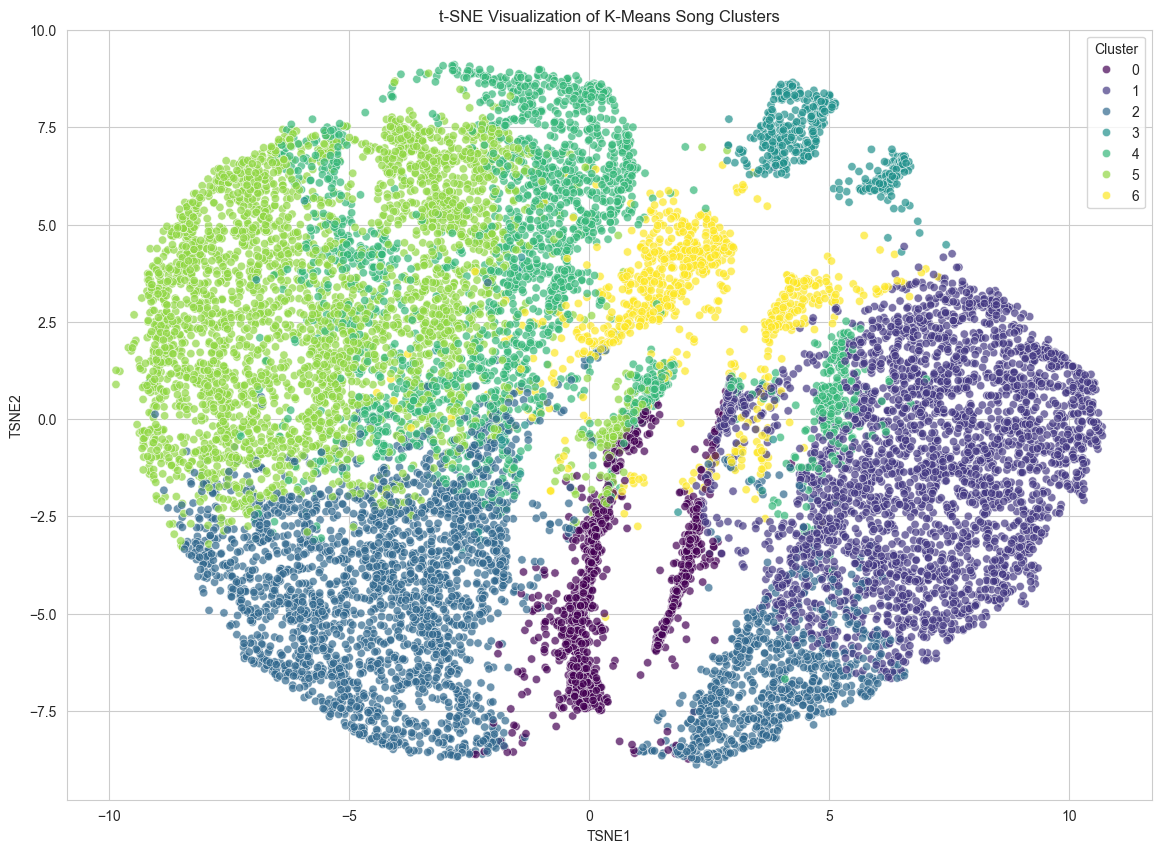


--- K-Means Clustering Evaluation ---
Silhouette Score: 0.1530
Davies-Bouldin Index: 1.7403
(Silhouette Score: Higher is better. Davies-Bouldin: Lower is better.)


In [33]:
# --- Visualize Clusters (t-SNE) ---
def visualize_clusters_tsne():
    print("\nGenerating t-SNE plot for K-Means clusters... (this may take a moment)")
    tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=300)
    df_tsne = tsne.fit_transform(df_sample)

    df_plot = pd.DataFrame(df_tsne, columns=['TSNE1', 'TSNE2'])
    df_plot['cluster'] = df_tracks_sample['cluster_kmeans'].values

    plt.figure(figsize=(14, 10))
    sns.scatterplot(data=df_plot, x='TSNE1', y='TSNE2', hue='cluster', palette='viridis', alpha=0.7)
    plt.title('t-SNE Visualization of K-Means Song Clusters')
    plt.legend(title='Cluster')
    plt.show()

# --- Radar Plot for Feature Comparison ---
def plot_radar_chart(track_name, recommended_track_name):
    """Creates a radar chart comparing two tracks' audio features."""
    track1 = get_track_details(track_name)
    track2 = get_track_details(recommended_track_name)

    if track1 is None or track2 is None:
        print(f"Could not find one of the tracks for radar plot: '{track_name}' or '{recommended_track_name}'")
        return

    features_to_plot = ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence']
    track1_features = df_features_scaled.loc[track1.name, features_to_plot]
    track2_features = df_features_scaled.loc[track2.name, features_to_plot]

    fig = go.Figure()
    fig.add_trace(go.Scatterpolar(r=track1_features, theta=features_to_plot, fill='toself', name=f"{track1['name']} (Original)"))
    fig.add_trace(go.Scatterpolar(r=track2_features, theta=features_to_plot, fill='toself', name=f"{track2['name']} (Recommended)"))
    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[-2.5, 2.5])),
        showlegend=True,
        title=f"Audio Feature Comparison: '{track1['name']}' vs '{track2['name']}'"
    )
    fig.show()


# --- Clustering Evaluation Metrics ---
def evaluate_clustering():
    """Calculates and prints clustering evaluation metrics."""
    if 'cluster_kmeans' not in df_tracks_sample.columns:
        print("K-Means clustering has not been run yet.")
        return

    silhouette = silhouette_score(df_sample, df_tracks_sample['cluster_kmeans'])
    davies_bouldin = davies_bouldin_score(df_sample, df_tracks_sample['cluster_kmeans'])

    print("\n--- K-Means Clustering Evaluation ---")
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
    print("(Silhouette Score: Higher is better. Davies-Bouldin: Lower is better.)")

print(f"\n\n{'='*50}")
print("📊 Running Visualizations & Evaluations")
print(f"{'='*50}")

visualize_clusters_tsne()
evaluate_clustering()


## Display Recommendations

In [50]:
## Putting It All Together: Get Recommendations**

# Test the recommenders with a song title.
input_track_name = "Bohemian Rhapsody - Remastered 2011" # @param {type:"string"}, Song input

if not tracks_df.empty:
    print(f"\n\n{'='*50}")
    print(f"🚀 Getting recommendations for: '{input_track_name}'")
    print(f"{'='*50}")

    print("\n--- 1. Content-Based Recommender ---")
    recs_content = content_based_recommender(input_track_name)

    print("\n\n--- 2. Hybrid Recommender (Content + Popularity) ---")
    recs_hybrid = hybrid_recommender(input_track_name)
   
    print("\n\n--- 3. K-Means Clustering Recommender ---")
    kmeans_recommender(input_track_name)

    
else:
    print("\n🚨 Cannot run recommendations because the dataset was not loaded.")




🚀 Getting recommendations for: 'Bohemian Rhapsody - Remastered 2011'

--- 1. Content-Based Recommender ---

--- Top Recommendations ---
  - Bohemian Rhapsody - Remastered 2011 by ['Queen']
  - 背著良心的說話 by ['Danny Chan', 'Bryan Choy Hin Lok', 'David Ling Jr. at Bali Studio']
  - Teringin by ['Shima']
  - De Waarheid by ['Marco Borsato']
  - Hard To Believe by ['Eraserheads']
  - Pílatus og Kristur by ['Daníel Ágúst Haraldsson']
  - Father of Creation - Live by ['Hillsong Worship', "Integrity's Hosanna! Music", 'Darlene Zschech']
  - I'm Not There by ['Bob Dylan']
  - Quédate by ['Los João']
  - 勉強幸福 by ['Yoga Lin']


--- 2. Hybrid Recommender (Content + Popularity) ---


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2972\1553086322.py:124: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  initial_recs['year'] = pd.to_datetime(initial_recs['release_date'], format='mixed').dt.year



--- Top Hybrid Recommendations (Content + Year + Popularity) ---
  - Was It Just Me by ['Douwe Bob'] | Year: 2021 | Popularity: 57
  - The Life of Ram by ['Pradeep Kumar'] | Year: 2018 | Popularity: 58
  - Pride by ['A-Reece', 'Rowlene'] | Year: 2017 | Popularity: 33
  - Selmas sang (fra Snøfall) by ['Eva Weel Skram'] | Year: 2016 | Popularity: 44
  - Irtha Ki Apopse Sta Skalopatia Sou by ['Giorgos Zambetas', 'Sakis Raspitsos'] | Year: 2015 | Popularity: 2
  - Somersetwes by ['Spoegwolf'] | Year: 2012 | Popularity: 36
  - 勉強幸福 by ['Yoga Lin'] | Year: 2012 | Popularity: 34
  - Sabiéndose De Los Descalzos (with Julieta Venegas) by ['Mercedes Sosa', 'Julieta Venegas'] | Year: 2009 | Popularity: 40
  - My Body Is a Cage by ['Arcade Fire'] | Year: 2007 | Popularity: 61
  - Electricity by ['Original Cast of Billy Elliot'] | Year: 2005 | Popularity: 46


--- 3. K-Means Clustering Recommender ---

--- Top Recommendations ---
  - V Myčce by ['Hm...']
  - Laughing at Life - Take 1 by ['Billie H